# 6. Model Building, Improvement & Comparison


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report,roc_curve
import joblib,os


In [2]:
# Load the cleaned and preprocessed data from Notebook 01
df = pd.read_csv('../data/processed_data.csv')

X = df.drop('Churn', axis=1)
y = df['Churn']

X.shape


(7043, 23)

In [3]:
y.shape


(7043,)

In [4]:
# Split data into training and test sets
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

X_train.shape


(5634, 23)

In [5]:
X_test.shape


(1409, 23)

In [6]:
# Scale continuous numeric features to improve model convergence.
# Fit the scaler on training data only, then apply it to both sets
# to avoid data leakage
scaler=StandardScaler()
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[cols_to_scale]=scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]=scaler.transform(X_test[cols_to_scale])


### Model Building (Logistic Regression)


In [7]:
model=LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred=model.predict(X_test)

y_pred[:10]


array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0])

In [8]:
# Evaluate overall accuracy
accuracy_score(y_test,y_pred)


0.8225691980127751

In [9]:
# Evaluate performance in detail using a confusion matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)


[[935 101]
 [149 224]]


In [10]:
# Evaluate precision, recall, and F1-score for both classes
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



## Model Improvement (Handling Class Imbalance)


In [11]:
model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)
print(classification_report(y_test, y_pred_balanced))


              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1036
           1       0.52      0.83      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.81      0.75      0.76      1409



##  Decision Tree


In [12]:
# Train a single Decision Tree as a baseline before moving to ensemble methods
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred_dt = dt_model.predict(X_test)


In [13]:
# Evaluate Decision Tree performance
print(classification_report(y_test, y_pred_dt))


              precision    recall  f1-score   support

           0       0.82      0.83      0.83      1036
           1       0.51      0.49      0.50       373

    accuracy                           0.74      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.74      0.74      0.74      1409



In [14]:
# Confusion Matrix for Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)


[[863 173]
 [192 181]]


##  Random Forest


In [15]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


In [16]:
# Evaluate Random Forest performance (precision, recall, f1 for each class)
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.87      0.84      0.85      1036
           1       0.59      0.65      0.62       373

    accuracy                           0.79      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.79      0.79      1409



In [17]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)


[[869 167]
 [130 243]]


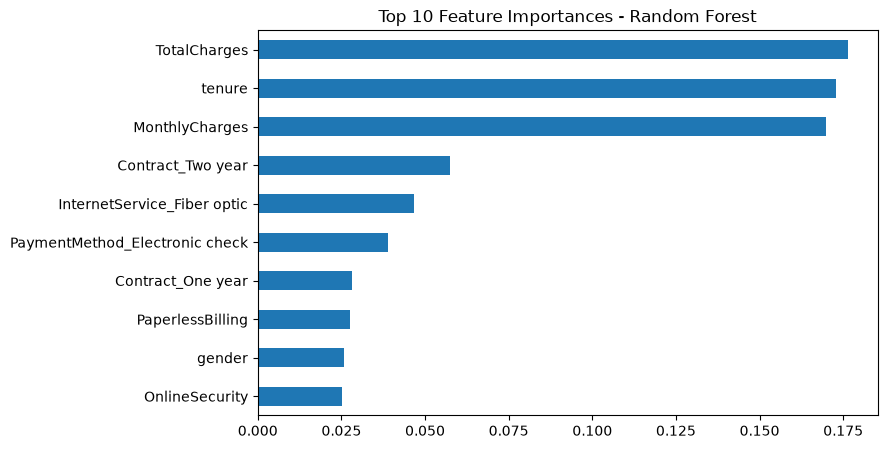

In [18]:
# Feature Importance - shows which features the model relied on most
# when making predictions. Higher value = more influence on the decision.
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances=importances.sort_values(ascending=False)

# Visualize the top 10 most important features
plt.figure(figsize=(8,5))
importances.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importances - Random Forest')
plt.gca().invert_yaxis()
plt.show()


##  XGBoost


In [19]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)


In [20]:
# Evaluate XGBoost performance
print(classification_report(y_test, y_pred_xgb))


              precision    recall  f1-score   support

           0       0.87      0.80      0.84      1036
           1       0.55      0.68      0.61       373

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409



In [21]:
# Confusion Matrix for XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)


[[831 205]
 [120 253]]


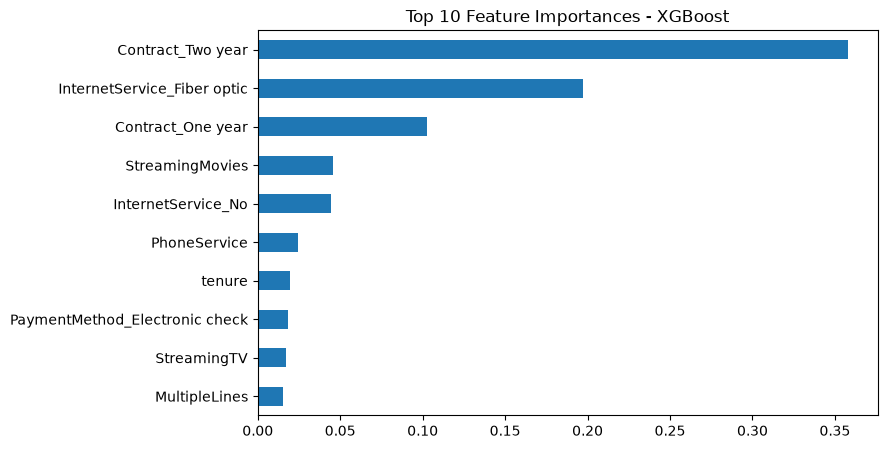

In [22]:
# Feature Importance for XGBoost
importances_xgb = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
importances_xgb = importances_xgb.sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances_xgb.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importances - XGBoost')
plt.gca().invert_yaxis()
plt.show()


##  Model Comparison


In [23]:
# Collect predictions and probability scores for all models
models_results = {
    'Logistic Regression': (y_pred_balanced, model_balanced.predict_proba(X_test)[:,1]),
    'Decision Tree': (y_pred_dt, dt_model.predict_proba(X_test)[:,1]),
    'Random Forest': (y_pred_rf, rf_model.predict_proba(X_test)[:,1]),
    'XGBoost': (y_pred_xgb, xgb_model.predict_proba(X_test)[:,1]),
}
# Calculate all metrics dynamically for each model
comparison_data = []
for name, (preds, probs) in models_results.items():
    comparison_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, pos_label=1),
        'Recall': recall_score(y_test, preds, pos_label=1),
        'F1-score': f1_score(y_test, preds, pos_label=1),
        'ROC-AUC': roc_auc_score(y_test, probs)
    })

comparison = pd.DataFrame(comparison_data)
comparison


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.750887,0.518456,0.828418,0.637771,0.862144
1,Decision Tree,0.740951,0.511299,0.485255,0.497937,0.659613
2,Random Forest,0.789212,0.592683,0.651475,0.620690,0.839697
3,XGBoost,0.769340,0.552402,0.678284,0.608905,0.838667


# Hyperparameter Tuning


In [24]:
#Define a small, reasonable range of values for C to test
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

# Search for the best C value using 5-fold cross-validation,
# optimizing for recall (our priority metric)
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_grid,
    scoring='recall',
    cv=5
)

grid_search.fit(X_train, y_train)

# Show the best parameter found
print("Best C:", grid_search.best_params_)
tuned_model = grid_search.best_estimator_
# Evaluate the tuned Logistic Regression model
y_pred_final = tuned_model.predict(X_test)
y_proba_final = tuned_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_final))


Best C: {'C': 1}
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1036
           1       0.52      0.83      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.81      0.75      0.76      1409

ROC-AUC: 0.8621437887523677


In [25]:
# Small, reasonable parameter grid to keep tuning fast
param_grid_xgb = {
    'max_depth': [3, 5],
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1]
}

grid_search_xgb = GridSearchCV(
    XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight, eval_metric='logloss'),
    param_grid_xgb,
    scoring='recall',
    cv=3  # 3-fold instead of 5, to speed things up
)

grid_search_xgb.fit(X_train, y_train)

print("Best params:", grid_search_xgb.best_params_)


Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


In [26]:
# Evaluate the tuned model
best_xgb = grid_search_xgb.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test)
y_proba_xgb_tuned = best_xgb.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_xgb_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb_tuned))


              precision    recall  f1-score   support

           0       0.93      0.72      0.81      1036
           1       0.52      0.85      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.75      0.77      1409

ROC-AUC: 0.8624349167244609


In [27]:
# Confusion Matrix for the final tuned XGBoost model
cm_final = confusion_matrix(y_test, y_pred_xgb_tuned)
print(cm_final)


[[743 293]
 [ 56 317]]


In [28]:
# Save the tuned model and scaler for the final insights notebook
os.makedirs('../models', exist_ok=True)
joblib.dump(best_xgb, '../models/best_xgb.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
print('Tuned model and scaler saved to ../models/')


Tuned model and scaler saved to ../models/
